## Análisis y Procesamiento de Señales, 2°C 2026
### Universidad Nacional de San Martín
#### Iara Alvarez Costa

# Tarea Semanal N°4
El objetivo de esta tarea semanal es estudiar las funciones de ventana utilizadas para disminuir la distorsion del espectro frecuencial de las señales durante su análisis.

## <u>Introducción</u>

En la tarea anterior se propuso la generación de señales senoidales de 3 frecuencias distintas pero muy cercanas en magnitud para estudiar el fenómeno de fuga espectral, el cual se produce cuando la energía correspondiente a cierto componente espectral se desparrama hacia los adyacentes y resulta en la distorsion del espectro frecuencial de la señal. Para eso, se tomó una cantidad finita de muestras de cada señal generada y finalmente se observó el espectro de la ventana implícita aplicada a cada señal.

Las funciones de ventana son funciones matemáticas que suelen utilizarse para poder seleccionar un trozo de la señal de interés antes de su análisis, y permite reducir la fuga espectral al modelar los datos de diversas formas.

En este ejercicio interesa estudiar diferentes funciones de ventana, su efecto en el espectro frecuencial para diferentes señales, y su influencia estadística en la estimación de ciertos parámetros espectrales.

## <u>Resolución</u>

Lo primero a hacer es armar las señales que se me piden para realizar el análisis. Debo terminar con 200 señales totales, donde cada una de las realizaciones consista de una senoidal estructurada de la forma
<div align=center>$x(n)=a_0.Sin(n.Ω_1)+n_a(n)$,    </div> 
cuya frecuencia difiere aleatoriamente para cada repeticion con distribución uniforme según:
<div align=center>$Ω_1=Ω_0 + f_r . \frac{2\pi}{N}$, </div> 
donde $Ω_0=\frac{\pi}{2}$, $a_0=\sqrt{2}$, y $f_r$ constituye una variable de probabilidad de distribucion uniforme: $f_r$ ~ $U(-2,2)$.
El ruido analógico acompañante para cada señal será de distribución gaussiana $n_a$ ~ $N(0,σ^2)$, y parametrizado a traves del SNR entre su potencia y el de su señal correspondiente $(P_n=10^{-\frac{SNR_{dB}}{P_x}})$






Con esto terminaré teniendo 200 señales de tipo $x_i(n)=a_0.Sin(n.{Ω_1}_i)+n_a(n)$, donde las frecuencias $Ω_1$ difieren entre cada iteración alrededor del valor $Ω_0=\frac{\pi}{2}$.



In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

"Parametros generales"
fs = 1000 #Frecuencia muestreo [Hz] 
N = 1000 #Cant. muestras para cada realizacion
reps = 200 #Cant de realizaciones

"Parámetros de senoidal"
vmax = np.sqrt(2) #Amp max senoidal
b = 2 #Distribución de la variable aleatoria
Px = vmax**2/2 #Potencia de señal [W]
Ω_0 = np.pi/2 #Frecuencia angular central [rad/s]
fr = np.random.uniform(-b, b, reps) #Variable aleatoria
Ω_1 = Ω_0 + fr*2*np.pi/N #Vector con 200 frecuencias aleatorias para la senoidal

"Parámetros secuencia de ruido"
ur = 0 #Media del ruido 
SNR = 3 #[dB]

Ahora, debido a la cantidad de datos que voy a necesitar almacenar (200 repeticiones con 1000 muestras para cada una), me va a convenir armar las señales mediante operaciones de matrices. 

Voy primero a armar una matriz con los argumentos de cada senoide de la forma:


<div align=center>$\begin{bmatrix} t_0 & t_0 & t_0 & ... & t_0 \\ t_1 & t_1 & t_1 & ... & t_1 \\ t_2 & t_2 & t_2 & ... & t_2 \\ \vdots & \vdots & \vdots &  & \vdots \\ t_{N-1} & t_{N-1} & t_{N-1} & ... & t_{N-1}\end{bmatrix}$   x   $\begin{bmatrix} Ω_{0,1} & Ω_{1,1} & Ω_{2,1} & ... & Ω_{199,1} \\ Ω_{0,1} & Ω_{1,1} & Ω_{2,1} & ... & Ω_{199,1} \\ Ω_{0,1} & Ω_{1,1} & Ω_{2,1} & ... & Ω_{199,1} \\ \vdots & \vdots & \vdots &  & \vdots \\ Ω_{0,1} & Ω_{1,1} & Ω_{2,1} & ... & Ω_{199,1}\end{bmatrix}$  =  $\begin{bmatrix} t_0.Ω_{0,1} & t_0.Ω_{1,1} & t_0.Ω_{2,1} & ... & t_0.Ω_{199,1} \\ t_1.Ω_{0,1} & t_1.Ω_{1,1} & t_1.Ω_{2,1} & ... & t_1.Ω_{199,1} \\ t_2.Ω_{0,1} & t_2.Ω_{1,1} & t_2.Ω_{2,1} & ... & t_2.Ω_{199,1} \\ \vdots & \vdots & \vdots &  & \vdots \\ t_{N-1}.Ω_{0,1} & t_{N-1}.Ω_{1,1} & t_{N-1}.Ω_{2,1} & ... & t_{N-1}.Ω_{199,1}\end{bmatrix}$</div>




In [75]:
"Matriz temporal"
t = np.arange(N) #Vector de indices de muestras
#Transpongo el vector t para que sea de 200x1, y armo la matriz temporal
tt_m = np.tile(t.reshape(-1, 1), (1, reps)) #Cada columna es una copia del vector t (reproduce 1 fila en 200 cols)

"Matriz frecuencial"
Ω_1.reshape(-1, 1) #Transpongo el vector de frecuencias
Ω_1_m = np.tile(Ω_1, (N, 1)) #(Reproduce 1 columna en 1000 filas)

"Matriz argumento de senoidal"
arg_m = tt_m * Ω_1_m


Ya tengo una matriz para poder generar todas las señales con una sola operación de $Sin()$:


In [76]:
"Genero todas las señales de un tirón"
xsen_m = vmax * np.sin(arg_m) #tengo en esta matriz 200 columnas correspondientes a cada repetición, y 1000 filas...
                              #...de muestras por cada repeticion

Ahora tengo una matriz donde cada columna contiene 1000 muestras de una misma senoidal a frecuencia angular $Ω_{i,1}$:
<div align=center>$\begin{bmatrix} Sin(t_0.Ω_{0,1}) & Sin(t_0.Ω_{1,1}) & Sin(t_0.Ω_{2,1}) & ... & Sin(t_0.Ω_{199,1}) \\ Sin(t_1.Ω_{0,1}) & Sin(t_1.Ω_{1,1}) & Sin(t_1.Ω_{2,1}) & ... & Sin(t_1.Ω_{199,1}) \\ \vdots & \vdots & \vdots &  & \vdots \\ Sin(t_{N-1}.Ω_{0,1}) & Sin(t_{N-1}.Ω_{1,1}) & Sin(t_{N-1}.Ω_{2,1}) & ... & Sin(t_{N-1}.Ω_{199,1})\end{bmatrix}$</div>

Similarmente, necesito una matriz con las secuencias de ruido analógico que voy a usar paa acompañar cada repeticion.

In [77]:
"Matriz de ruido analógico"
#Despejo la potencia del ruido en funcion al SNR y la potencia senoidal
Pn = Px / (10**(SNR/10))
desv_est_r = np.sqrt(Pn)
#Genero una matriz de 200 x 1000 donde cada fila es una secuencia de ruido de distribucion uniforme
na_m = np.random.normal(ur, desv_est_r, (N, reps))

Ahora solo debo sumar las 2 matrices para tener todas las señales contaminadas que voy a usar.

In [78]:
"Contamino las señales"
#Armo matriz de 1000 x 200 donde cada columna almacena las muestras de una misma señal contaminada
noisy_xsen_m = xsen_m + na_m

<div align=center>$\begin{bmatrix} Sin(t_0.Ω_{0,1}) + n_{a,0} & Sin(t_0.Ω_{1,1})+ n_{a,1} & ... & Sin(t_0.Ω_{199,1})+ n_{a,199} \\ Sin(t_1.Ω_{0,1})+ n_{a,0} & Sin(t_1.Ω_{1,1})+ n_{a,1} & ... & Sin(t_1.Ω_{199,1})+ n_{a,199} \\ \vdots & \vdots &  & \vdots \\ Sin(t_{N-1}.Ω_{0,1})+ n_{a,0} & Sin(t_{N-1}.Ω_{1,1})+ n_{a,1} & ... & Sin(t_{N-1}.Ω_{199,1})+ n_{a,199}\end{bmatrix}$</div>

Ahora es cuando voy a aplicar las funciones de ventana que me interesa analizar. Voy a aplicar 4 ventanas diferentes a la matriz de señales armada arriba: 
>- La ventana implícita (que ya está aplicada por tener un numero finito de muestras)
>- Flattop
>- Blackman-Harris
>- Ventana Hann (elección propia)

In [79]:
"Preparo las funciones de ventana que voy a usar"    
#Creo vectores de 1000x1 con los valores de 1000 muestras de cada ventana
rect = np.ones(N)
flat = signal.windows.flattop(N)
blackhar = signal.windows.blackmanharris(N)
hann = signal.windows.hann(N) #Voy a usar la ventana de Hann como 4ta elección

"Armo una matriz de señales por cada ventana a aplicar"
#transpongo los vectores de cada ventana para poder hacer el producto 
sign_rect = noisy_xsen_m * rect.reshape(-1,1)
sign_flat = noisy_xsen_m * flat.reshape(-1,1)
sign_blackhar = noisy_xsen_m * blackhar.reshape(-1,1)
sign_hann = noisy_xsen_m * hann.reshape(-1,1)

"Transformo las señales ventaneadas verticalmente"
X_rect = np.fft.fft(sign_rect, axis=0) / N
X_flat = np.fft.fft(sign_flat, axis=0) / N
X_blackhar = np.fft.fft(sign_blackhar, axis=0) / N
X_hann = np.fft.fft(sign_hann, axis=0) / N


Ya tenemos 4 matrices diferentes consistentes en cada una de las 200 realizaciones senoidales ventaneadas por una función distinta, transformadas, y normalizadas en magnitud. Ahora puedo pasar a los estimadores de interés.

<u> Estimador de amplitud </u>

Para la codificación del estimador de amplitud, que voy a definir como la magnitud de la transformada de la señal ventaneada <div align=center>$(â_{0,i}=|F(x_i(n).w(n))|=|X_i(Ω_0)|)$,</div> evaluaré las señales transformadas en el bin correspondiente a $Ω_0$ , $k_0$. 

Sabiendo que la grilla de bins de la DFT está dada por: $Ω_k=k. \frac{2π}{N}$ , el bin asociado a la frecuencia central $Ω_0=\frac{π}{2}$ sería $k_0=\frac{π}{2} . \frac{N}{2π} = 250$. Entonces, $k_0=250$.

In [80]:
k0 = int(np.pi/2 * N/(2*np.pi))

"Estimador amplitud"
#Armo un vector por ventana conteniendo las magnitudes de las 200 señales, evaluadas en k0
a1_rect = np.abs(X_rect[k0, :])
a1_flat = np.abs(X_flat[k0, :])
a1_blackhar = np.abs(X_blackhar[k0, :])
a1_hann = np.abs(X_hann[k0, :])

Con esto tengo para cada uno de los 4 sets de señales ventaneadas:

<div align=center>$a_{1,i} = ${$â_{1,0} ; â_{1,1} ; â_{1,2} ; ... ; â_{1,199}$}</div>

<u> Estimador de frecuencia </u>

La implementacion de este estimador es también bastante directo.
Conceptualmente, busco la fecuencia correspondiente a la maxor amplitud espectral para cada realización ventaneada.
, que voy a definir como la magnitud de la transformada de la señal ventaneada <div align=center>$\widehat{\Omega}_i=arg max_f${$|X_i(Ω_0)|$}$,</div> 

En la práctica, obtendré el bin correspondiente al mencionado máximo de amplitud, el cual puedo relacionar con la frecuencia de acuerdo a$f_k=k\frac{f_s}{N}$. Como en este caso$f_s$ y $N$ son del mismo modulo, la resolución frecuencial es de $Δf = 1Hz$, y el valor de la frecuencia coincide con el de bin.
El estimador devolverá la frecuencia asociada al índice de DFT más cercano a la frecuencia real de cada señal.

In [81]:
"Estimador frecuencia"
#Armo un vector con los indices correspondientes al mayor valor abs de cada realizacion en cada ventana
frec_rect = np.argmax(np.abs(X_rect[:N//2, :]), axis=0) #(selecciono la mitad positiva del rango de señales)
frec_flat = np.argmax(np.abs(X_flat[:N//2, :]), axis=0)
frec_blackhar = np.argmax(np.abs(X_blackhar[:N//2, :]), axis=0)
frec_hann = np.argmax(np.abs(X_hann[:N//2, :]), axis=0)

#Convierto los indices a frecuencias angulares
omega_rect = frec_rect * 2*np.pi/N
omega_flat = frec_flat * 2*np.pi/N
omega_blackhar = frec_blackhar * 2*np.pi/N
omega_hann = frec_hann * 2*np.pi/N

Ahora tengo para cada set de señales los valores estimados de frecuencia angular correspondientes al indice de bin asociado a la amplitud máxima de la señal: <div align=center>$\widehat{\Omega}_{1,i} = ${$\widehat{\Omega}_{1,0} ; \widehat{\Omega}_{1,1} ; \widehat{\Omega}_{1,2} ; ... ; \widehat{\Omega}_{1,199}$}</div>


### <u>Cálculos estadísticos</u>

Lo que me interesa analizar a través de los respectivos estimadores es el sesgo y la varianza asociados a los datos modificados por cada ventana.
El <i><b>sesgo</i></b> de un estimador es la diferencia entre su valor esperado y el real.
<div align=center>$s_a = E${$â_0$} $-a_0$</div>
<div align=center>$s_{\Omega} = E${$\widehat{\Omega}_0$} $-\Omega_0$</div>
Tanto para amplitud como para frecuencia, me dará una idea de qué tan "buena" es la estimación que obtuve con cada ventana. Se podrá dar una idea del sesgo mirando la donde se centran los valores estimados en los histogramas.


La <i><b>varianza</i></b> de cada estimador será indicativa de qué tanto difieren las estimaciones en cada set de señales respecto a la media, lo cual se podrá observar en el ancho de distribución de los valores en los histogramas.
<div align=center>$var${$â_0$}$ = E${$(â_0 - E${$â_0$}$)^2$}</div>
<div align=center>$var${$\Omega_0$}$ = E${$(\widehat{\Omega}_0 - E${$\widehat{\Omega}_0$}$)^2$}</div>


Ademas de la observación gráfica, puedo calcular el sesgo y la varianza aproximados de los estimadores de cada ventana para comparar numericamente, si aproximo los valores esperados por las medias muestrales:
<div align=center>$E${$â_0$} $=\widehat{μ_a}$</div>
<div align=center>$E${$\widehat{\Omega}_0$} $=\widehat{μ_{\Omega}}$</div>

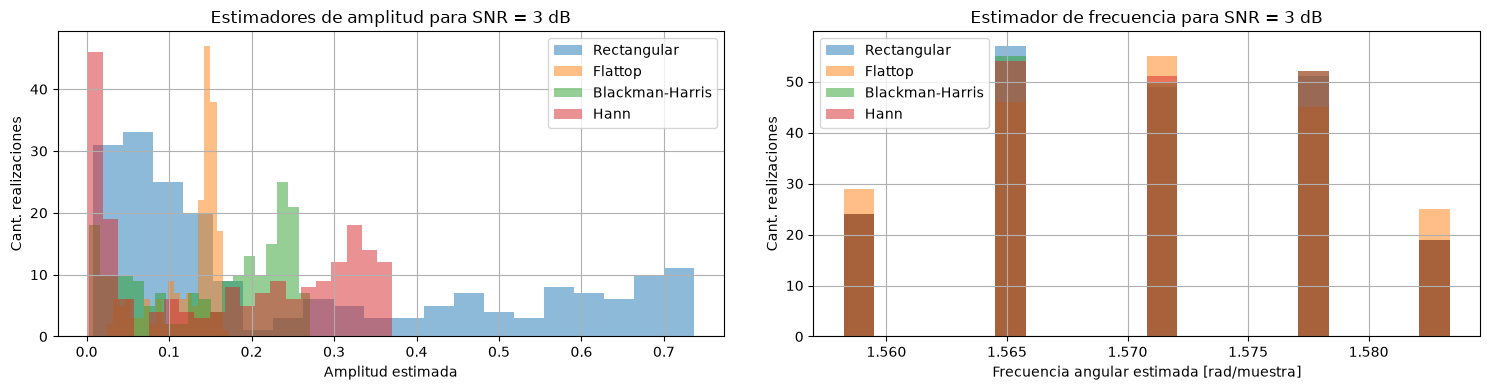


							 RESULTADOS ESTADÍSTICOS - SNR = 3 dB

					Ventana               Sesgo a0       Var{a0}      Sesgo Ω         Var{Ω}
					--------------------------------------------------------------------------
					Rectangular         -1.151873       0.057640     0.000007       0.000003
					Flattop             -1.288779       0.001375     0.000227       0.000007
					Blackman-Harris     -1.263547       0.007668     0.000101       0.000003
					Hann                -1.240206       0.017500     0.000133       0.000003


In [82]:

"Sesgo de estimadores amplitud"
ses_a_rect = np.mean(a1_rect) - vmax
ses_a_flat = np.mean(a1_flat) - vmax
ses_a_blackhar = np.mean(a1_blackhar) - vmax
ses_a_hann = np.mean(a1_hann) - vmax

"Sesgo estimadores frec."
ses_f_rect = np.mean(omega_rect - Ω_1)
ses_f_flat = np.mean(omega_flat - Ω_1)
ses_f_blackhar = np.mean(omega_blackhar - Ω_1)
ses_f_hann = np.mean(omega_hann - Ω_1)


"Varianza estimadores amplitud"
var_a_rect = np.mean((a1_rect - np.mean(a1_rect))**2)
var_a_flat = np.mean((a1_flat - np.mean(a1_flat))**2)
var_a_blackhar = np.mean((a1_blackhar - np.mean(a1_blackhar))**2)
var_a_hann = np.mean((a1_hann - np.mean(a1_hann))**2)

"Varianza estimadores frecuencia"
var_f_rect = np.mean(((omega_rect - Ω_1) - np.mean(omega_rect - Ω_1))**2)
var_f_flat = np.mean(((omega_flat - Ω_1) - np.mean(omega_flat - Ω_1))**2)
var_f_blackhar = np.mean(((omega_blackhar - Ω_1) - np.mean(omega_blackhar - Ω_1))**2)
var_f_hann = np.mean(((omega_hann - Ω_1) - np.mean(omega_hann - Ω_1))**2)


"Histograma estimadores de amplitud"
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].hist(a1_rect, bins=20, alpha=0.5, label="Rectangular")
axs[0].hist(a1_flat, bins=20, alpha=0.5, label="Flattop")
axs[0].hist(a1_blackhar, bins=20, alpha=0.5, label="Blackman-Harris")
axs[0].hist(a1_hann, bins=20, alpha=0.5, label="Hann")
axs[0].set_title("Estimadores de amplitud para SNR = " + str(SNR) + " dB")
axs[0].set_xlabel("Amplitud estimada")

"Histograma estimadores de frecuencia"
axs[1].hist(omega_rect, bins=20, alpha=0.5, label="Rectangular")
axs[1].hist(omega_flat, bins=20, alpha=0.5, label="Flattop")
axs[1].hist(omega_blackhar, bins=20, alpha=0.5, label="Blackman-Harris")
axs[1].hist(omega_hann, bins=20, alpha=0.5, label="Hann")
axs[1].set_title("Estimador de frecuencia para SNR = " + str(SNR) + " dB")
axs[1].set_xlabel("Frecuencia angular estimada [rad/muestra]")

for ax in axs.flat:
    ax.set_ylabel("Cant. realizaciones")
    ax.grid()
    ax.legend()

plt.tight_layout(w_pad=3)
plt.show()

print("\n\t\t\t\t\t\t    ==============================================")
print("\t\t\t\t\t\t\t RESULTADOS ESTADÍSTICOS - SNR =", SNR, "dB")
print("\t\t\t\t\t\t    ==============================================")

print("\n\t\t\t\t\tVentana               Sesgo a0       Var{a0}      Sesgo Ω         Var{Ω}")
print("\t\t\t\t\t--------------------------------------------------------------------------")
print(f"\t\t\t\t\tRectangular         {ses_a_rect:9.6f}    {var_a_rect:11.6f}    {ses_f_rect:9.6f}    {var_f_rect:11.6f}")
print(f"\t\t\t\t\tFlattop             {ses_a_flat:9.6f}    {var_a_flat:11.6f}    {ses_f_flat:9.6f}    {var_f_flat:11.6f}")
print(f"\t\t\t\t\tBlackman-Harris     {ses_a_blackhar:9.6f}    {var_a_blackhar:11.6f}    {ses_f_blackhar:9.6f}    {var_f_blackhar:11.6f}")
print(f"\t\t\t\t\tHann                {ses_a_hann:9.6f}    {var_a_hann:11.6f}    {ses_f_hann:9.6f}    {var_f_hann:11.6f}")

### <b><u>Análisis</b></u>

><u>Amplitud</u>

> Inmediatamente salta a la vista que la distribucion de valores estimados para la amplitud no se asemejan en lo absoluto a $a_0$. Primero cabe recalcar que por mera naturaleza de la definición del estimador. $(â_0=|X_i(Ω_0)|)$ evalúa el modulo de la transformada en la frecuencia central $Ω_0$, que es fija; pero la frecuencia real de cada realización difiere de la central como $f_r.\frac{2\pi}{N}$, por la frecuencia angular real $Ω_1$ no suele coincidir con el valor en el que se realiza la estimación. Esto termina produciendo desparramo espectral para cada iteracion en la que $Ω_0≠Ω_1$ y una discrepancia entre $â_0$ y la amplitud real.

> Pero esto no es lo que más contribuye a la discrepancia de datos. Los otros factores que afectan a las estimaciones son la normalización de la DFT, y el efecto de la ganancia de cada ventana.
> Una funcion de ventana actúa como una envolvente que modifica la forma del desparramo espectral.
> Al aplicar una ventana dada sobre un set de señales $(x_i(n).\omega(n))$ se modifica la amplitud de la señal de acuerdo a la ganancia de cada ventana. Además, la respuesta en frecuencia de una ventana también influye en cuanto discrepará el valor estimado de $â_0$ con el real:

C:\Users\Iarulis\AppData\Local\Temp\ipykernel_3212\1066164227.py:15: RuntimeWarning: divide by zero encountered in log10
  W_rect_dB = 20 * np.log10(np.abs(W_rect) / np.max(np.abs(W_rect)))


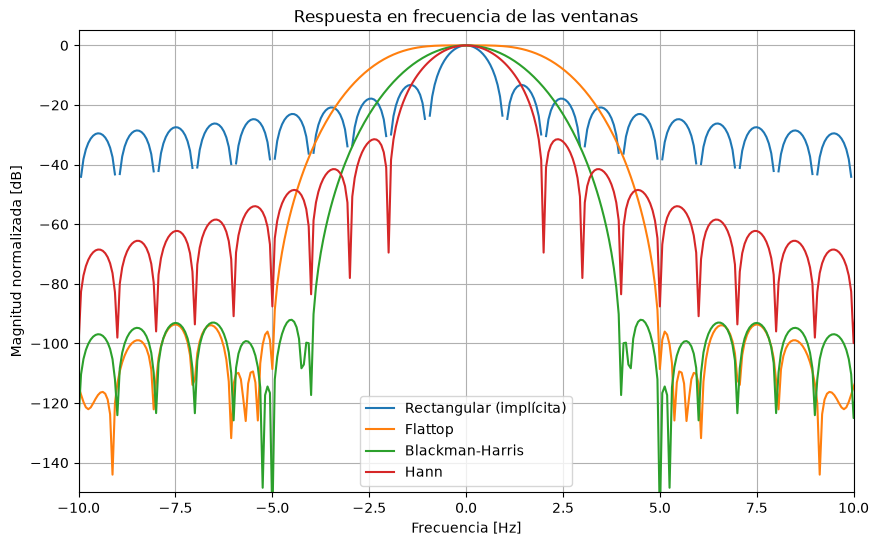

In [83]:
"Gráficos de respuesta en frecuencia de las ventanas usadas para ilustrar el análisis (hecho con IA)"
# Zero padding para obtener una respuesta en frecuencia más suave
Nfft = 16 * N

# FFT de cada ventana con la frecuencia 0 desplazada al centro
W_rect = np.fft.fftshift(np.fft.fft(rect, Nfft))
W_flat = np.fft.fftshift(np.fft.fft(flat, Nfft))
W_blackhar = np.fft.fftshift(np.fft.fft(blackhar, Nfft))
W_hann = np.fft.fftshift(np.fft.fft(hann, Nfft))

# Vector de frecuencias
f = np.fft.fftshift(np.fft.fftfreq(Nfft, 1/fs))

# Magnitud normalizada y expresada en dB
W_rect_dB = 20 * np.log10(np.abs(W_rect) / np.max(np.abs(W_rect)))
W_flat_dB = 20 * np.log10(np.abs(W_flat) / np.max(np.abs(W_flat)))
W_blackhar_dB = 20 * np.log10(np.abs(W_blackhar) / np.max(np.abs(W_blackhar)))
W_hann_dB = 20 * np.log10(np.abs(W_hann) / np.max(np.abs(W_hann)))

# Gráfico
plt.figure(figsize=(10, 6))

plt.plot(f, W_rect_dB, label="Rectangular (implícita)")
plt.plot(f, W_flat_dB, label="Flattop")
plt.plot(f, W_blackhar_dB, label="Blackman-Harris")
plt.plot(f, W_hann_dB, label="Hann")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud normalizada [dB]")
plt.title("Respuesta en frecuencia de las ventanas")
plt.xlim(-10, 10)
plt.ylim(-150, 5)
plt.grid()
plt.legend()
plt.show()

> La ventana implicita, por ejemplo, tieneel lobulo principal más angosto en relación a las otras ventanas, por lo que atenúa de forma mas "agresiva" los valores contiguos al asociado a la frecuencia central. Cuando la frecuencia de la señal se aleja de $Ω_0$, la magnitud medida $|X(Ω_0)|$ cae de forma más pronunciada. En otras palabras, un lóbulo principal más estrecho resulta en un menor sesgo, aumenta el efecto del desalineamiento frecuencial sobre la estimación, y resulta en una mayor dispersion de valores en relación a la media, es decir, una mayor varianza, como se aprecia en la tabla de datos.

> Es por esto también que la varianza de amplitud estimada para la ventana flattop (la de lóbulo más ancho), es la menor de todas. Se puede apreciar tanto en la tabla de valores como en la concentración de la distribución de datos en el histograma de aplitudes estimadas.

><u>Frecuencia</u>

>La primera observación de interés es el orden del sesgo y varianza para los estimadores de todas las ventanas. En cada caso, los sesgos son del orden de $10^{-4},$ y las varianzas del orden de $10^{-6}$, lo cual indica que el efecto de las ventanas sobre la estimación del máximo de la señal es mucho menos evidente al que tienen sobre la magnitud del espectro.

>Lo segundo, y mas visualmente evidente, es la agrupación de las estimaciones en valores claramente espaciados.

>Ya sé que los valores de la grilla de bins de la DFT están separados una cantidad $\Delta\Omega=\frac{2π}{N}$, por lo que $argmax$ devuelve solo indices enteros asociados a las frecuencias estimadas $(k=248$ , $249$ , $250$ , ...$)$, y el estimador de frecuencia queda entonces cuantizado como $\widehat{\Omega}=k.\Delta\Omega=k.\frac{2π}{N}$

<b>Ahora que ya obtuve los resultados de sesgo y varianza para los estimadores de cada set de señales para un SNR de 3 dB, repetiré el experimento para un SNR de 10 dB:</b>

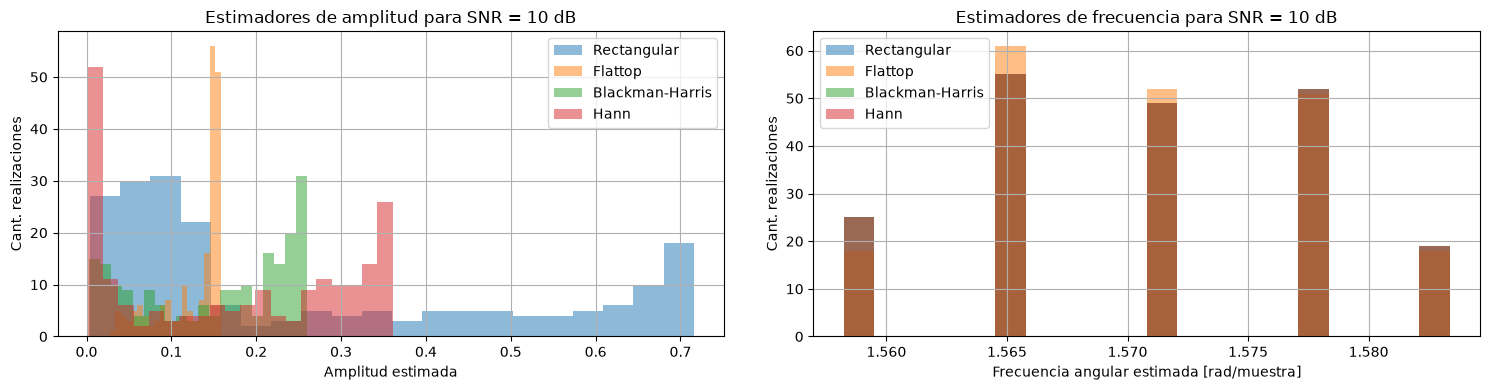


							 RESULTADOS ESTADÍSTICOS - SNR = 10 dB

					Ventana               Sesgo a0       Var{a0}      Sesgo Ω         Var{Ω}
					--------------------------------------------------------------------------
					Rectangular         -1.152715       0.058803     0.000038       0.000003
					Flattop             -1.287795       0.001298     0.000195       0.000005
					Blackman-Harris     -1.262826       0.007690     0.000038       0.000003
					Hann                -1.241146       0.018127     0.000038       0.000003


In [84]:
SNR = 10 #[dB]

"Matriz de ruido analógico"
Pn = Px / (10**(SNR/10))
desv_est_r = np.sqrt(Pn)
na_m = np.random.normal(ur, desv_est_r, (N, reps))
"Contamino las señales"
noisy_xsen_m = xsen_m + na_m
"Armo los sets de señales ventaneadas"
sign_rect = noisy_xsen_m * rect.reshape(-1,1)
sign_flat = noisy_xsen_m * flat.reshape(-1,1)
sign_blackhar = noisy_xsen_m * blackhar.reshape(-1,1)
sign_hann = noisy_xsen_m * hann.reshape(-1,1)
"Transformo las señales ventaneadas verticalmente"
X_rect = np.fft.fft(sign_rect, axis=0) / N
X_flat = np.fft.fft(sign_flat, axis=0) / N
X_blackhar = np.fft.fft(sign_blackhar, axis=0) / N
X_hann = np.fft.fft(sign_hann, axis=0) / N

"Estimador amplitud"
a1_rect = np.abs(X_rect[k0, :])
a1_flat = np.abs(X_flat[k0, :])
a1_blackhar = np.abs(X_blackhar[k0, :])
a1_hann = np.abs(X_hann[k0, :])
"Estimador frecuencia"
frec_rect = np.argmax(np.abs(X_rect[:N//2, :]), axis=0)
frec_flat = np.argmax(np.abs(X_flat[:N//2, :]), axis=0)
frec_blackhar = np.argmax(np.abs(X_blackhar[:N//2, :]), axis=0)
frec_hann = np.argmax(np.abs(X_hann[:N//2, :]), axis=0)
#Convierto los indices a frecuencias angulares
omega_rect = frec_rect * 2*np.pi/N
omega_flat = frec_flat * 2*np.pi/N
omega_blackhar = frec_blackhar * 2*np.pi/N
omega_hann = frec_hann * 2*np.pi/N

"Sesgo de estimadores amplitud"
ses_a_rect = np.mean(a1_rect) - vmax
ses_a_flat = np.mean(a1_flat) - vmax
ses_a_blackhar = np.mean(a1_blackhar) - vmax
ses_a_hann = np.mean(a1_hann) - vmax
"Sesgo estimadores frec."
ses_f_rect = np.mean(omega_rect - Ω_1)
ses_f_flat = np.mean(omega_flat - Ω_1)
ses_f_blackhar = np.mean(omega_blackhar - Ω_1)
ses_f_hann = np.mean(omega_hann - Ω_1)

"Varianza estimadores amplitud"
var_a_rect = np.mean((a1_rect - np.mean(a1_rect))**2)
var_a_flat = np.mean((a1_flat - np.mean(a1_flat))**2)
var_a_blackhar = np.mean((a1_blackhar - np.mean(a1_blackhar))**2)
var_a_hann = np.mean((a1_hann - np.mean(a1_hann))**2)
"Varianza estimadores frecuencia"
var_f_rect = np.mean(((omega_rect - Ω_1) - np.mean(omega_rect - Ω_1))**2)
var_f_flat = np.mean(((omega_flat - Ω_1) - np.mean(omega_flat - Ω_1))**2)
var_f_blackhar = np.mean(((omega_blackhar - Ω_1) - np.mean(omega_blackhar - Ω_1))**2)
var_f_hann = np.mean(((omega_hann - Ω_1) - np.mean(omega_hann - Ω_1))**2)

"Histograma estimadores de amplitud"
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].hist(a1_rect, bins=20, alpha=0.5, label="Rectangular")
axs[0].hist(a1_flat, bins=20, alpha=0.5, label="Flattop")
axs[0].hist(a1_blackhar, bins=20, alpha=0.5, label="Blackman-Harris")
axs[0].hist(a1_hann, bins=20, alpha=0.5, label="Hann")
axs[0].set_title("Estimadores de amplitud para SNR = " + str(SNR) + " dB")
axs[0].set_xlabel("Amplitud estimada")
"Histograma estimadores de frecuencia"
axs[1].hist(omega_rect, bins=20, alpha=0.5, label="Rectangular")
axs[1].hist(omega_flat, bins=20, alpha=0.5, label="Flattop")
axs[1].hist(omega_blackhar, bins=20, alpha=0.5, label="Blackman-Harris")
axs[1].hist(omega_hann, bins=20, alpha=0.5, label="Hann")
axs[1].set_title("Estimadores de frecuencia para SNR = " + str(SNR) + " dB")
axs[1].set_xlabel("Frecuencia angular estimada [rad/muestra]")
for ax in axs.flat:
    ax.set_ylabel("Cant. realizaciones")
    ax.grid()
    ax.legend()
plt.tight_layout(w_pad=3)
plt.show()

print("\n\t\t\t\t\t\t    ==============================================")
print("\t\t\t\t\t\t\t RESULTADOS ESTADÍSTICOS - SNR =", SNR, "dB")
print("\t\t\t\t\t\t    ==============================================")

print("\n\t\t\t\t\tVentana               Sesgo a0       Var{a0}      Sesgo Ω         Var{Ω}")
print("\t\t\t\t\t--------------------------------------------------------------------------")
print(f"\t\t\t\t\tRectangular         {ses_a_rect:9.6f}    {var_a_rect:11.6f}    {ses_f_rect:9.6f}    {var_f_rect:11.6f}")
print(f"\t\t\t\t\tFlattop             {ses_a_flat:9.6f}    {var_a_flat:11.6f}    {ses_f_flat:9.6f}    {var_f_flat:11.6f}")
print(f"\t\t\t\t\tBlackman-Harris     {ses_a_blackhar:9.6f}    {var_a_blackhar:11.6f}    {ses_f_blackhar:9.6f}    {var_f_blackhar:11.6f}")
print(f"\t\t\t\t\tHann                {ses_a_hann:9.6f}    {var_a_hann:11.6f}    {ses_f_hann:9.6f}    {var_f_hann:11.6f}")

### <b><u>Análisis</b></u>

Inmediatamente salta a la vista que, si bien se sigue notando el patron de dependencia, observado en el 1er experimento, entre los sesgos y varianzas de amplitud con el tipo de ventana; los valores de varianza obtenidos en esta instancia son comparativamente mayores, y los sesgos menores.

Si la potencia media de las señales permanece constante, como en este caso, un mayor valor de SNR supone secuencias de ruido analógico menos potentes.
Para una relación $SNR = 3 dB$, la mayor potencia de ruido acompañante afecta la media del estimador, las discrepancias entre las amplitudes estimadas y reales se ven disminuidas por la adición de valores aleatorios de significativa magnitud.

Cuando el $SNR$ aumenta a $10 dB$, la senoide predomina sobre el ruido analógico, y resulta más evidente el efecto del desplazamiento de frecuencia sobre los estimadores, y su dispersión para cada set de señales.
